
CAGR SUMMARY
Metric           Historical 2018-2024    Forecast 2020-2041
------------------------------------------------------------
  Population                    6.51%                 5.68%
  Meat                          6.51%                 6.21%
  Milk                          6.51%                 5.54%
  Feed                            n/a                 5.71%


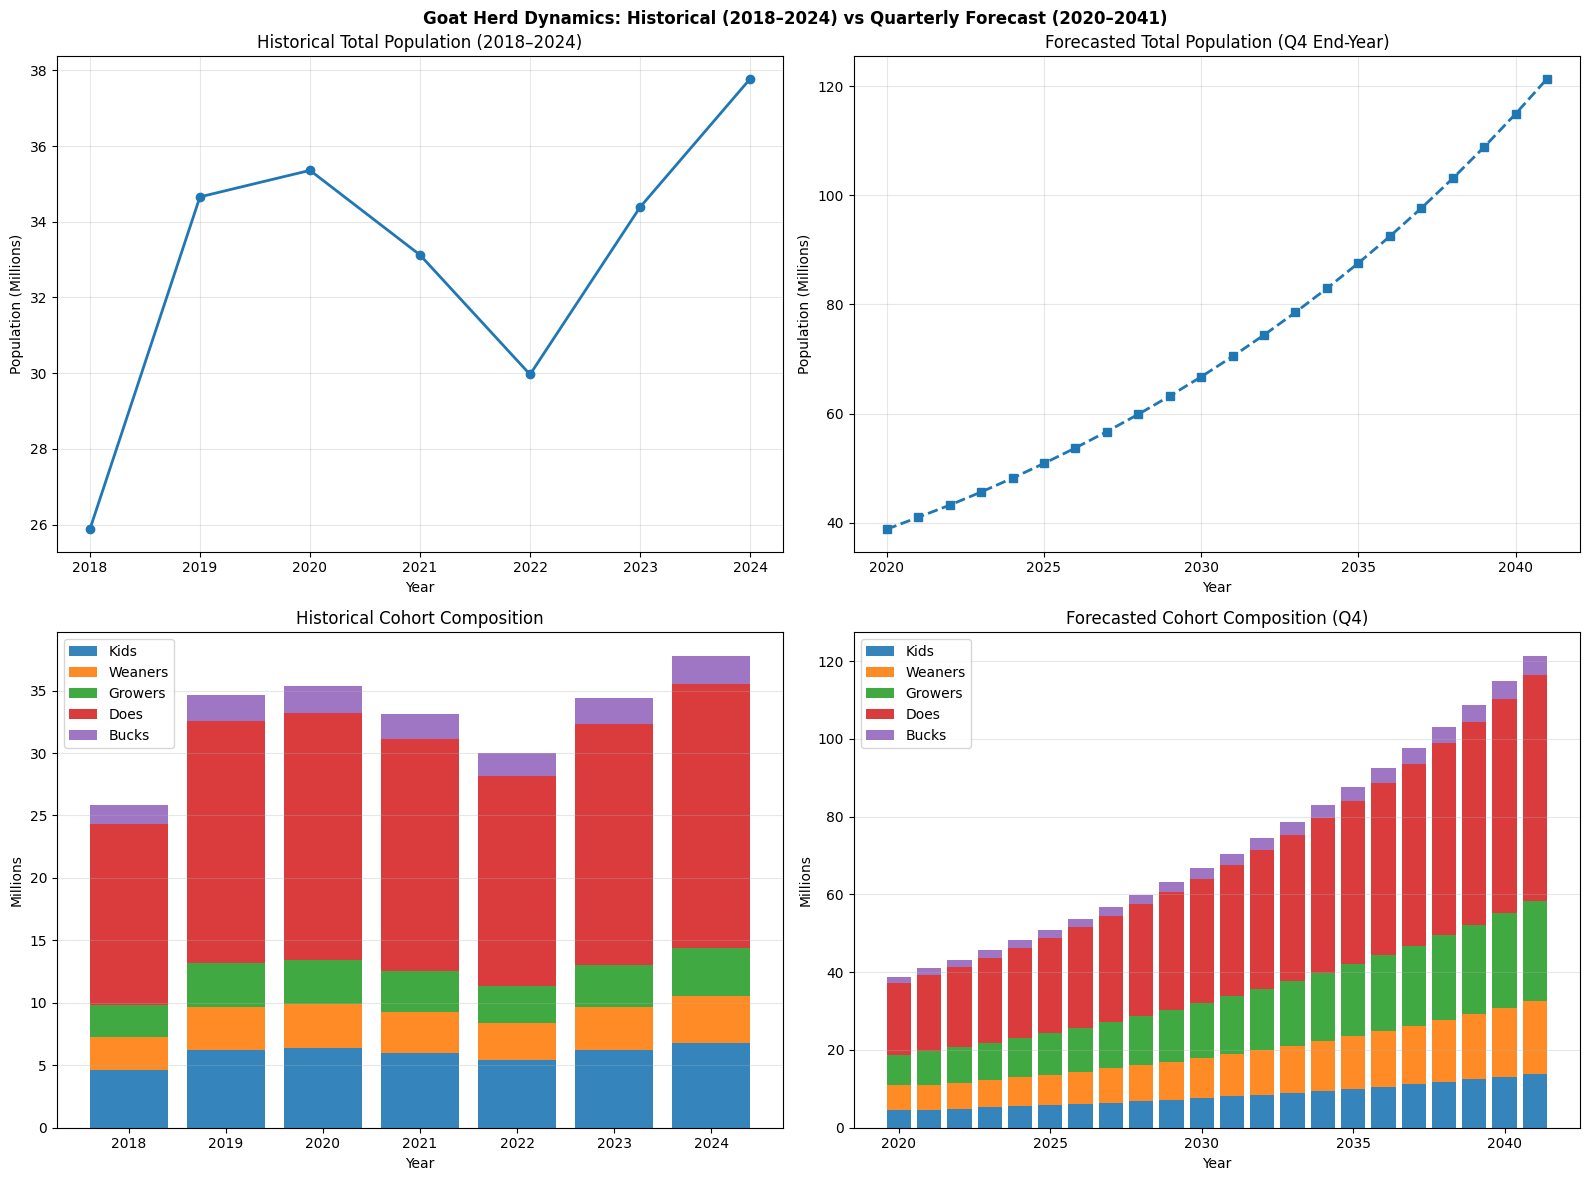

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# PARAMETERS
# ============================================================================

HISTORICAL_YEARS  = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
HISTORICAL_TOTALS = [25876113, 34657969, 35358674, 33123213, 29965055, 34385998, 37776633]
HERD0 = HISTORICAL_TOTALS[HISTORICAL_YEARS.index(2019)]

SEX_RATIO    = 0.50   # female
LITTER_SIZE  = 1.20
KIDDING_RATE = 1.10

KID_MORTALITY           = 0.24
WEANER_MORTALITY        = 0.09
GROWER_MORTALITY        = 0.06
OVERALL_ADULT_MORTALITY = 0.05

OFFTAKE_RATE_GROWERS = 0.18
OFFTAKE_RATE_DOES    = 0.10
OFFTAKE_RATE_BUCKS   = 0.55

CULL_RATE_DOES_ANNUAL  = 0.04
CULL_RATE_BUCKS_ANNUAL = 0.03

TARGET_BUCK_PROP = 0.04

PROD_PARAMS = {
    'does': {
        'carcass_yield_pct':    0.48,
        'avg_live_weight_kg':   38.0,
        'lactating_fraction':   0.40,
        'milk_yield_l_per_day': 0.40,
        'lactating_days':       200
    },
    'bucks':   {'carcass_yield_pct': 0.50, 'avg_live_weight_kg': 48.0},
    'growers': {'carcass_yield_pct': 0.45, 'avg_live_weight_kg': 30.0}
}

HISTORICAL_PROPORTIONS = {
    'kids':    0.18,
    'weaners': 0.10,
    'growers': 0.10,
    'does':    0.56,
    'bucks':   0.06
}

FEED_PARAMS = {
    'kids':    {'dmi_pct': 0.035, 'kid_w': 3.0},
    'weaners': {'dmi_pct': 0.04,  'weaner_w': 22.0},
    'growers': {'dmi_pct': 0.045, 'grower_w': 30.0},
    'does':    {'dmi_pct': 0.023, 'doe_w': 38.0},
    'bucks':   {'dmi_pct': 0.023, 'buck_w': 48.0}
}

P_KID_WEANER     = 0.76
P_WEANER_GROWER  = 0.50
P_GROWER_ADULT   = 0.30

DQ = 365.25 / 4.0
FORECAST_YEARS = 22
T_QUARTERS     = FORECAST_YEARS * 4

# ============================================================================
# FUNCTIONS
# ============================================================================

def to_q(q):
    return 1.0 - (1.0 - q) ** 0.25

m_k_q = to_q(KID_MORTALITY)
m_w_q = to_q(WEANER_MORTALITY)
m_g_q = to_q(GROWER_MORTALITY)
m_a_q = to_q(OVERALL_ADULT_MORTALITY)

o_g_q = to_q(OFFTAKE_RATE_GROWERS)
o_d_q = to_q(OFFTAKE_RATE_DOES)
o_b_q = to_q(OFFTAKE_RATE_BUCKS)

c_d_q = to_q(CULL_RATE_DOES_ANNUAL)
c_b_q = to_q(CULL_RATE_BUCKS_ANNUAL)

# ============================================================================
# INITIAL STATE
# ============================================================================

K_total = HERD0 * HISTORICAL_PROPORTIONS['kids']
Kf = K_total * SEX_RATIO
Km = K_total * (1 - SEX_RATIO)

W = HERD0 * HISTORICAL_PROPORTIONS['weaners']
G = HERD0 * HISTORICAL_PROPORTIONS['growers']
D = HERD0 * HISTORICAL_PROPORTIONS['does']
B = HERD0 * HISTORICAL_PROPORTIONS['bucks']

records = []

# ============================================================================
# SIMULATION
# ============================================================================

for t in range(T_QUARTERS):

    year = 2020 + t // 4
    qtr  = (t % 4) + 1

    pop_start = Kf + Km + W + G + D + B

    # ======================
    # MORTALITY
    # ======================
    Kf1 = Kf * (1 - m_k_q)
    Km1 = Km * (1 - m_k_q)
    W1  = W  * (1 - m_w_q)
    G1  = G  * (1 - m_g_q)
    D1  = D  * (1 - m_a_q)
    B1  = B  * (1 - m_a_q)

    # ======================
    # CULLING
    # ======================
    D2 = D1 * (1 - c_d_q)
    B2 = B1 * (1 - c_b_q)

    # ======================
    # OFFTAKE
    # ======================
    G2 = G1 * (1 - o_g_q)
    D3 = D2 * (1 - o_d_q)
    B3 = B2 * (1 - o_b_q)

    # ======================
    # SURVIVORS
    # ======================
    Kf_surv = Kf1
    Km_surv = Km1
    W_surv  = W1
    G_surv  = G2
    D_surv  = D3
    B_surv  = B3

    # ======================
    # TRANSITIONS
    # ======================
    T_KW_f = Kf_surv * P_KID_WEANER
    T_KW_m = Km_surv * P_KID_WEANER

    T_WG = W_surv * P_WEANER_GROWER
    T_GA = G_surv * P_GROWER_ADULT

    # sex split at adult entry
    T_GA_d = T_GA * SEX_RATIO
    T_GA_b = T_GA * (1 - SEX_RATIO)

    # ======================
    # BIRTHS (SEX SPLIT)
    # ======================
    births_total = D_surv * (1 - PROD_PARAMS['does']['lactating_fraction']) * (KIDDING_RATE * LITTER_SIZE) / 4.0
    births_f = births_total * SEX_RATIO
    births_m = births_total * (1 - SEX_RATIO)

    # ======================
    # UPDATE
    # ======================
    Kf_next = Kf_surv - T_KW_f + births_f
    Km_next = Km_surv - T_KW_m + births_m

    W_next = W_surv - T_WG + (T_KW_f + T_KW_m)
    G_next = G_surv - T_GA + T_WG

    D_next = D_surv + T_GA_d
    B_next = B_surv + T_GA_b

    # ======================
    # BUCK CAP ENFORCEMENT
    # ======================
    total_pre_cap = Kf_next + Km_next + W_next + G_next + D_next + B_next
    max_bucks = total_pre_cap * TARGET_BUCK_PROP

    excess_bucks = max(0, B_next - max_bucks)

    if excess_bucks > 0:
        B_next -= excess_bucks  # forced offtake

    # ======================
    # FINAL POPULATION
    # ======================
    pop_end = Kf_next + Km_next + W_next + G_next + D_next + B_next

    # ======================
    # MEAT (includes forced buck removal)
    # ======================
    meat = (
        G1 * o_g_q * PROD_PARAMS['growers']['avg_live_weight_kg'] * PROD_PARAMS['growers']['carcass_yield_pct']
        + D1 * c_d_q * PROD_PARAMS['does']['avg_live_weight_kg'] * PROD_PARAMS['does']['carcass_yield_pct']
        + D2 * o_d_q * PROD_PARAMS['does']['avg_live_weight_kg'] * PROD_PARAMS['does']['carcass_yield_pct']
        + B1 * c_b_q * PROD_PARAMS['bucks']['avg_live_weight_kg'] * PROD_PARAMS['bucks']['carcass_yield_pct']
        + B2 * o_b_q * PROD_PARAMS['bucks']['avg_live_weight_kg'] * PROD_PARAMS['bucks']['carcass_yield_pct']
        + excess_bucks * PROD_PARAMS['bucks']['avg_live_weight_kg'] * PROD_PARAMS['bucks']['carcass_yield_pct']
    )

    # ======================
    # MILK
    # ======================
    milk = (
        D_surv * PROD_PARAMS['does']['lactating_fraction']
        * PROD_PARAMS['does']['milk_yield_l_per_day']
        * PROD_PARAMS['does']['lactating_days'] / 4.0
    )

    # ======================
    # FEED
    # ======================
    feed = (
        (Kf_surv + Km_surv) * FEED_PARAMS['kids']['kid_w'] * FEED_PARAMS['kids']['dmi_pct'] * DQ
        + W_surv * FEED_PARAMS['weaners']['weaner_w'] * FEED_PARAMS['weaners']['dmi_pct'] * DQ
        + G_surv * FEED_PARAMS['growers']['grower_w'] * FEED_PARAMS['growers']['dmi_pct'] * DQ
        + D_surv * FEED_PARAMS['does']['doe_w'] * FEED_PARAMS['does']['dmi_pct'] * DQ
        + B_surv * FEED_PARAMS['bucks']['buck_w'] * FEED_PARAMS['bucks']['dmi_pct'] * DQ
    )

    records.append({
        "year": year,
        "quarter": qtr,
        "population_start": pop_start,
        "population_end": pop_end,
        "kids": Kf_next + Km_next,
        "weaners": W_next,
        "growers": G_next,
        "does": D_next,
        "bucks": B_next,
        "meat_kg": meat,
        "milk_l": milk,
        "feed_intake_kg": feed
    })

    Kf, Km, W, G, D, B = Kf_next, Km_next, W_next, G_next, D_next, B_next

forecast_df = pd.DataFrame(records)
forecast_df['cal_year'] = forecast_df['year'] + (forecast_df['quarter'] - 1)/4

# ============================================================================
# ANNUAL (Q4 ONLY)
# ============================================================================

forecast_annual = forecast_df[forecast_df['quarter'] == 4].copy()
forecast_annual = forecast_annual.rename(columns={
    "population_start": "total_start",
    "population_end": "total_end"
})

# ============================================================================
# HISTORICAL
# ============================================================================

historical_df = pd.DataFrame({
    "year": HISTORICAL_YEARS,
    "total": HISTORICAL_TOTALS
})

for k in HISTORICAL_PROPORTIONS:
    historical_df[k] = historical_df["total"] * HISTORICAL_PROPORTIONS[k]

def historical_production(df):
    out = []
    for _, r in df.iterrows():
        dp, bp, gp = PROD_PARAMS['does'], PROD_PARAMS['bucks'], PROD_PARAMS['growers']
        meat = (
            r['does']    * OFFTAKE_RATE_DOES    * dp['avg_live_weight_kg'] * dp['carcass_yield_pct'] +
            r['bucks']   * OFFTAKE_RATE_BUCKS   * bp['avg_live_weight_kg'] * bp['carcass_yield_pct'] +
            r['growers'] * OFFTAKE_RATE_GROWERS * gp['avg_live_weight_kg'] * gp['carcass_yield_pct']
        )
        milk = r['does'] * dp['lactating_fraction'] * dp['milk_yield_l_per_day'] * dp['lactating_days']
        out.append({'year': r['year'], 'meat_kg': meat, 'milk_l': milk})
    return pd.DataFrame(out)

historical_prod_df = historical_production(historical_df)

# ============================================================================
# CAGR CALCULATION
# ============================================================================

def cagr(start, end, n):
    return (end / start) ** (1.0 / n) - 1.0

hist_pop  = historical_df
hist_prod = historical_prod_df

h_cagr_pop  = cagr(hist_pop.loc[hist_pop.year==2018,'total'].values[0],
                   hist_pop.loc[hist_pop.year==2024,'total'].values[0], 6)
h_cagr_meat = cagr(hist_prod.loc[hist_prod.year==2018,'meat_kg'].values[0],
                   hist_prod.loc[hist_prod.year==2024,'meat_kg'].values[0], 6)
h_cagr_milk = cagr(hist_prod.loc[hist_prod.year==2018,'milk_l'].values[0],
                   hist_prod.loc[hist_prod.year==2024,'milk_l'].values[0], 6)

fa0  = forecast_annual[forecast_annual.year == 2020].iloc[0]
fa22 = forecast_annual[forecast_annual.year == 2041].iloc[0]
f_cagr_pop  = cagr(fa0['total_start'], fa22['total_end'],  21)
f_cagr_meat = cagr(fa0['meat_kg'],     fa22['meat_kg'],    21)
f_cagr_milk = cagr(fa0['milk_l'],      fa22['milk_l'],     21)
f_cagr_feed = cagr(fa0['feed_intake_kg'], fa22['feed_intake_kg'],21)

print("\nCAGR SUMMARY")
print(f"{'Metric':<14} {'Historical 2018-2024':>22}  {'Forecast 2020-2041':>20}")
print("-" * 60)
for name, hv, fv in [("Population", h_cagr_pop, f_cagr_pop),
                      ("Meat",       h_cagr_meat, f_cagr_meat),
                      ("Milk",       h_cagr_milk, f_cagr_milk),
                      ("Feed",       float('nan'), f_cagr_feed)]:
    hstr = f"{hv:.2%}" if not np.isnan(hv) else "  n/a"
    print(f"  {name:<12} {hstr:>22}  {fv:>20.2%}")

print("=" * 80)

# ============================================================================
# VISUALIZATION 1 — HERD DYNAMICS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Goat Herd Dynamics: Historical (2018–2024) vs Quarterly Forecast (2020–2041)',
    fontsize=12, fontweight='bold'
)

ax = axes[0, 0]
ax.plot(historical_df['year'], historical_df['total']/1e6, marker='o', linewidth=2)
ax.set_title('Historical Total Population (2018–2024)')
ax.set_ylabel('Population (Millions)'); ax.set_xlabel('Year'); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(forecast_annual['year'], forecast_annual['total_end']/1e6,
        marker='s', linewidth=2, linestyle='--')
ax.set_title('Forecasted Total Population (Q4 End-Year)')
ax.set_ylabel('Population (Millions)'); ax.set_xlabel('Year'); ax.grid(alpha=0.3)

coh    = ['kids', 'weaners', 'growers', 'does', 'bucks']

ax = axes[1, 0]
b = np.zeros(len(historical_df))
for c in coh:
    ax.bar(historical_df['year'], historical_df[c]/1e6, bottom=b, label=c.capitalize(), alpha=0.9)
    b += historical_df[c].values / 1e6
ax.set_title('Historical Cohort Composition'); ax.set_ylabel('Millions')
ax.set_xlabel('Year'); ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
b = np.zeros(len(forecast_annual))
for c in coh:
    ax.bar(forecast_annual['year'], forecast_annual[c]/1e6, bottom=b, label=c.capitalize(), alpha=0.9)
    b += forecast_annual[c].values / 1e6
ax.set_title('Forecasted Cohort Composition (Q4)')
ax.set_ylabel('Millions'); ax.set_xlabel('Year')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# # ============================================================================
# # VISUALIZATION 2 — PRODUCTION
# # ============================================================================

# fig, axes = plt.subplots(3, 1, figsize=(14, 12))
# fig.suptitle('Goat Production Metrics')

# ax = axes[0]
# ax.plot(forecast_df['year'], forecast_df['meat_kg']/1e6)
# ax.set_title('Meat Production'); ax.grid(alpha=0.3)

# ax = axes[1]
# ax.plot(forecast_df['year'], forecast_df['milk_l']/1e6)
# ax.set_title('Milk Production'); ax.grid(alpha=0.3)

# ax = axes[2]
# ax.plot(forecast_df['year'], forecast_df['feed_intake_kg']/1e6)
# ax.set_title('Feed Intake'); ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

In [2]:
def build_herd_structure_table(historical_df, forecast_df):

    years = list(range(2019, 2042))

    rows = [
        "Kids",
        "Weaners",
        "Growers",
        "Does",
        "Bucks",
        "Total Goats"
    ]

    table = pd.DataFrame(index=rows, columns=years)

    # baseline
    base = historical_df[historical_df["year"] == 2019].iloc[0]

    table.loc["Kids", 2019] = base["kids"]
    table.loc["Weaners", 2019] = base["weaners"]
    table.loc["Growers", 2019] = base["growers"]
    table.loc["Does", 2019] = base["does"]
    table.loc["Bucks", 2019] = base["bucks"]
    table.loc["Total Goats", 2019] = base["total"]

    # forecast years
    for _, r in forecast_df.iterrows():

        y = int(r["year"])

        table.loc["Kids", y] = r["kids"]
        table.loc["Weaners", y] = r["weaners"]
        table.loc["Growers", y] = r["growers"]
        table.loc["Does", y] = r["does"]
        table.loc["Bucks", y] = r["bucks"]
        table.loc["Total Goats", y] = r["population_end"]

    table.insert(0, "Herd Structure", table.index)
    table.insert(0, "Value chain", "Goat")

    return table.reset_index(drop=True)

# Build the table
herd_table = build_herd_structure_table(historical_df, forecast_df)

# Save to Excel
herd_table.to_excel("herd_structure_07042026.xlsx", index=False)

In [4]:
def build_herd_tables(historical_df, forecast_df, historical_prod_df, output_path="herd_structure_07042026.xlsx"):
    years = list(range(2018, 2042))

    # ── PRE-AGGREGATE FORECAST ────────────────────────────────────────────────
    # Sum production across all 4 quarters per year
    forecast_annual_prod = (
        forecast_df
        .groupby("year")[["meat_kg", "milk_l", "feed_intake_kg"]]
        .sum()
        .reset_index()
    )
    # Population: end-of-year = Q4 snapshot
    forecast_annual_pop = forecast_df[forecast_df["quarter"] == 4].copy()

    # ── SHEET 1: Herd Structure ───────────────────────────────────────────────
    cohort_rows = ["Kids", "Weaners", "Growers", "Does", "Bucks", "Total Goats"]
    sources     = ["Actual", "Model"]

    index1 = pd.MultiIndex.from_product([cohort_rows, sources], names=["Cohort", "Source"])
    sheet1 = pd.DataFrame(index=index1, columns=years, dtype=object)

    for _, r in historical_df.iterrows():
        y = int(r["year"])
        sheet1.loc[("Kids",        "Actual"), y] = r["kids"]
        sheet1.loc[("Weaners",     "Actual"), y] = r["weaners"]
        sheet1.loc[("Growers",     "Actual"), y] = r["growers"]
        sheet1.loc[("Does",        "Actual"), y] = r["does"]
        sheet1.loc[("Bucks",       "Actual"), y] = r["bucks"]
        sheet1.loc[("Total Goats", "Actual"), y] = r["total"]

    # Use Q4 snapshot for cohort headcounts (stock, not flow)
    for _, r in forecast_annual_pop.iterrows():
        y = int(r["year"])
        sheet1.loc[("Kids",        "Model"), y] = r["kids"]
        sheet1.loc[("Weaners",     "Model"), y] = r["weaners"]
        sheet1.loc[("Growers",     "Model"), y] = r["growers"]
        sheet1.loc[("Does",        "Model"), y] = r["does"]
        sheet1.loc[("Bucks",       "Model"), y] = r["bucks"]
        sheet1.loc[("Total Goats", "Model"), y] = r["population_end"]

    sheet1 = sheet1.reset_index()
    sheet1.insert(0, "Value Chain", "Goat")

    # ── SHEET 2: Production Metrics ───────────────────────────────────────────
    prod_rows = [
        "Total Population",
        "Meat Production (kg)",
        "Milk Production (L)",
        "Feed Intake (kg DM)",
    ]
    index2 = pd.MultiIndex.from_product([prod_rows, sources], names=["Metric", "Source"])
    sheet2 = pd.DataFrame(index=index2, columns=years, dtype=object)

    for _, r in historical_df.iterrows():
        y = int(r["year"])
        sheet2.loc[("Total Population", "Actual"), y] = r["total"]

    for _, r in historical_prod_df.iterrows():
        y = int(r["year"])
        sheet2.loc[("Meat Production (kg)", "Actual"), y] = r["meat_kg"]
        sheet2.loc[("Milk Production (L)",  "Actual"), y] = r["milk_l"]

    # Population: Q4 stock; production: summed across all 4 quarters
    for _, r in forecast_annual_pop.iterrows():
        y = int(r["year"])
        sheet2.loc[("Total Population", "Model"), y] = r["population_end"]

    for _, r in forecast_annual_prod.iterrows():
        y = int(r["year"])
        sheet2.loc[("Meat Production (kg)", "Model"), y] = r["meat_kg"]
        sheet2.loc[("Milk Production (L)",  "Model"), y] = r["milk_l"]
        sheet2.loc[("Feed Intake (kg DM)",  "Model"), y] = r["feed_intake_kg"]

    sheet2 = sheet2.reset_index()
    sheet2.insert(0, "Value Chain", "Goat")

    # ── WRITE ─────────────────────────────────────────────────────────────────
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        sheet1.to_excel(writer, sheet_name="Herd Structure",     index=False)
        sheet2.to_excel(writer, sheet_name="Production Metrics", index=False)

    return sheet1, sheet2


sheet1, sheet2 = build_herd_tables(
    historical_df,
    forecast_df,
    historical_prod_df,
    output_path="goats_07042026.xlsx"
)